## Exploratory Data Analysis: Heart Disease UCI Dataset

This notebook performs the initial data acquisition review and exploratory data analysis for the Heart Disease UCI dataset. The goal of this stage is to understand the structure, quality, distribution, and predictive characteristics of the dataset before model development.

The dataset contains patient-level clinical attributes such as age, sex, chest pain type, resting blood pressure, cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate, exercise-induced angina, ST depression, slope, number of major vessels, thalassemia status, and the heart disease diagnosis target.

For this project, the target variable is treated as a binary classification label:

- `0`: No heart disease
- `1`: Presence of heart disease

This binary target structure aligns with the assignment objective of developing a classifier that predicts heart disease risk.

### 1. Import Required Libraries

The required Python libraries are imported in this section.

- `pandas` and `numpy` are used for data loading, cleaning, and numerical operations.
- `matplotlib` and `seaborn` are used for professional data visualizations.
- `pathlib` is used to manage file paths in a clean and operating-system-independent way.

The figures generated in this notebook are saved to the `reports/figures/` folder so they can be included later in the final report.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_PATH = Path("../data/processed/heart_disease_clean.csv")
FIGURE_PATH = Path("../reports/figures")
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

### 2. Load the Cleaned Dataset

The cleaned Heart Disease dataset is loaded from the `data/processed/` folder. This file was generated by the data download script after retrieving the dataset from the UCI Machine Learning Repository.

At this stage, the dataset has already been converted into a binary classification format where the target column indicates whether heart disease is absent or present.

### 3. Initial Dataset Preview

The first few rows of the dataset are displayed to understand the available columns, data format, and general structure of the records.

This preview helps confirm that the dataset was loaded correctly and that the target column is available for classification modeling.

In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


### 4. Dataset Structure and Data Types

This section reviews the structure of the dataset, including:

- Number of rows and columns
- Column names
- Data types
- Non-null value counts

Understanding data types is important because numerical and categorical variables require different preprocessing steps during model development. For example, numerical features may need scaling, while categorical features may need encoding.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


### 5. Summary Statistics

Descriptive statistics are generated for the dataset to understand the central tendency, spread, and range of each feature.

This includes values such as mean, standard deviation, minimum, maximum, and quartiles. These statistics are useful for identifying potential outliers, unusual feature ranges, skewed distributions, or variables that may require preprocessing before modeling.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### 6. Missing Value Analysis

Missing value analysis is performed to identify incomplete records in the dataset.

Handling missing values is an important preprocessing step because most machine learning algorithms cannot directly process missing data. In this project, missing values will be handled later inside a reproducible preprocessing pipeline. This approach ensures that missing value treatment is applied consistently during both training and inference.

The missing value count and percentage are calculated for each feature.

In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percent": missing_percent
})

missing_summary

,missing_count,missing_percent
ca,4,1.320132
thal,2,0.660066
cp,0,0.000000
trestbps,0,0.000000
age,0,0.000000
sex,0,0.000000
fbs,0,0.000000
chol,0,0.000000
restecg,0,0.000000
thalach,0,0.000000


#### Missing Value Visualization

The missing value bar chart provides a quick visual summary of missing data across all features.

Features with missing values may require imputation during preprocessing. Numerical features can be imputed using strategies such as median imputation, while categorical features can be imputed using the most frequent category.

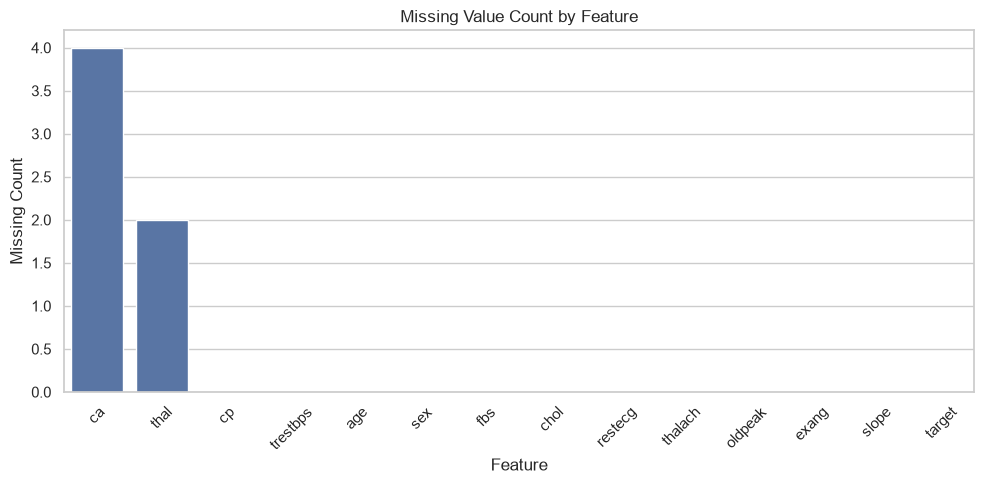

In [6]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=missing_summary.index,
    y=missing_summary["missing_count"]
)
plt.xticks(rotation=45)
plt.title("Missing Value Count by Feature")
plt.ylabel("Missing Count")
plt.xlabel("Feature")
plt.tight_layout()
plt.savefig(FIGURE_PATH / "missing_values.png", dpi=300)
plt.show()

### 7. Target Class Distribution

The target variable represents the presence or absence of heart disease.

Class distribution analysis is important because imbalanced target classes can affect model training and evaluation. If one class is much more frequent than the other, accuracy alone may be misleading. In that case, metrics such as precision, recall, F1-score, and ROC-AUC become more important.

In [7]:
class_counts = df["target"].value_counts().sort_index()
class_counts

target
0    164
1    139
Name: count, dtype: int64

#### Class Balance Visualization

The class distribution plot shows the number of patients in each target class.

A reasonably balanced dataset allows the model to learn patterns from both classes. If a major imbalance is observed, additional steps such as stratified train-test splitting, class weighting, or resampling may be considered during model development.

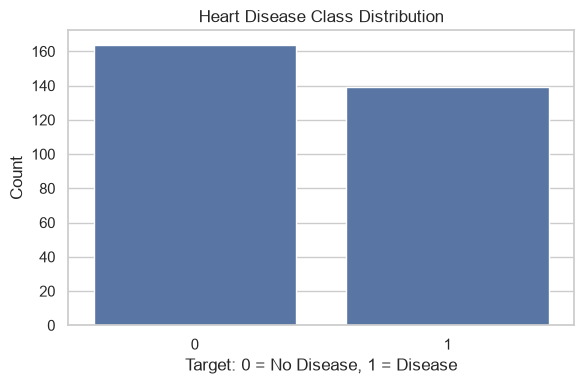

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target")
plt.title("Heart Disease Class Distribution")
plt.xlabel("Target: 0 = No Disease, 1 = Disease")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURE_PATH / "class_distribution.png", dpi=300)
plt.show()

### 8. Numerical Feature Distributions

Histograms are used to visualize the distribution of each numerical feature.

This helps identify:

- Skewed variables
- Outliers
- Unusual value ranges
- Features that may benefit from scaling
- Differences in spread between variables

For models such as Logistic Regression, feature scaling is especially important because the model is sensitive to the magnitude of input variables. Tree-based models such as Random Forest are generally less sensitive to scaling.

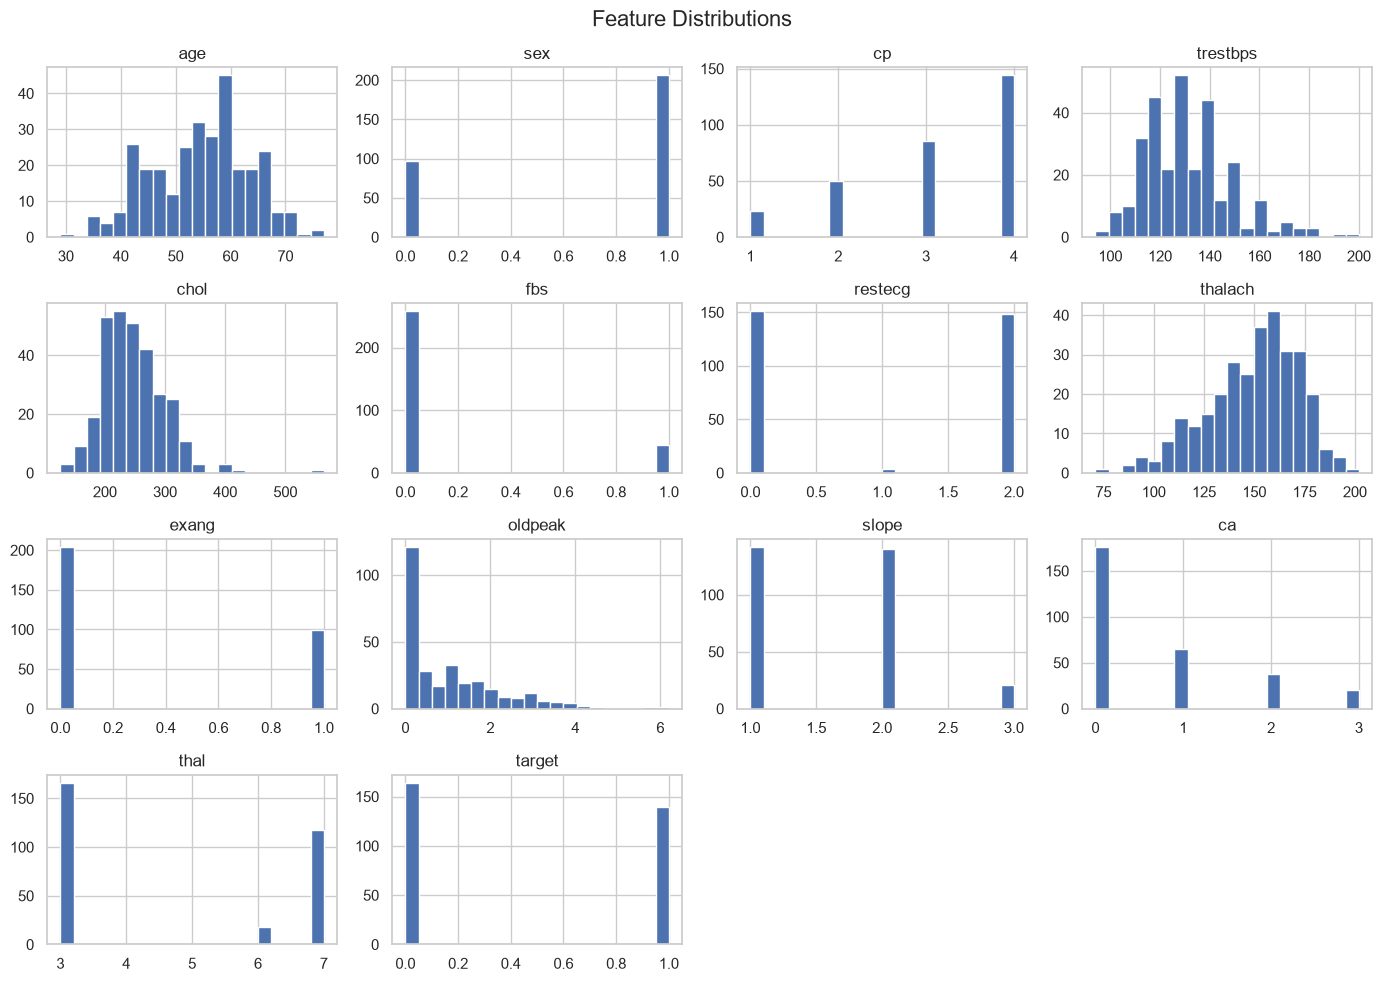

In [9]:
df.hist(figsize=(14, 10), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.savefig(FIGURE_PATH / "feature_histograms.png", dpi=300)
plt.show()

### 9. Correlation Analysis

A correlation heatmap is used to evaluate the strength and direction of relationships between numerical variables.

Correlation values range from `-1` to `+1`:

- Values close to `+1` indicate a strong positive relationship.
- Values close to `-1` indicate a strong negative relationship.
- Values close to `0` indicate little or no linear relationship.

This analysis helps identify features that may be strongly related to the target variable. It also helps detect highly correlated input features, which may introduce redundancy in some models.

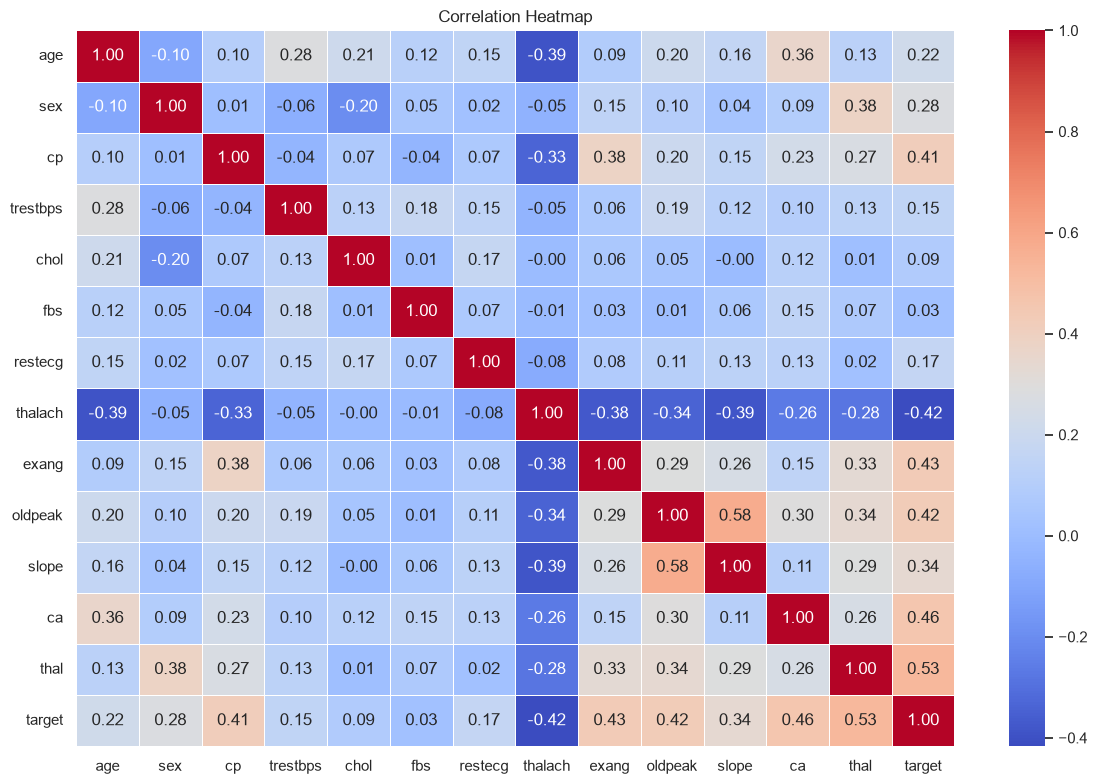

In [10]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIGURE_PATH / "correlation_heatmap.png", dpi=300)
plt.show()

### 10. Numerical Feature Relationships with Target

Boxplots are used to compare numerical feature distributions across the two target classes.

This analysis helps determine whether patients with and without heart disease show visible differences in clinical variables such as:

- Age
- Resting blood pressure
- Cholesterol
- Maximum heart rate achieved
- ST depression induced by exercise

Features that show clear separation between the two classes may provide useful predictive information for the classification models.

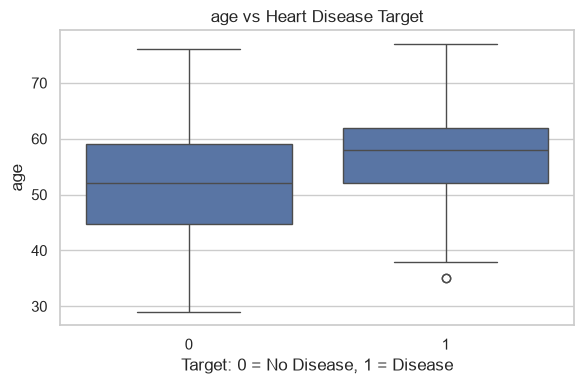

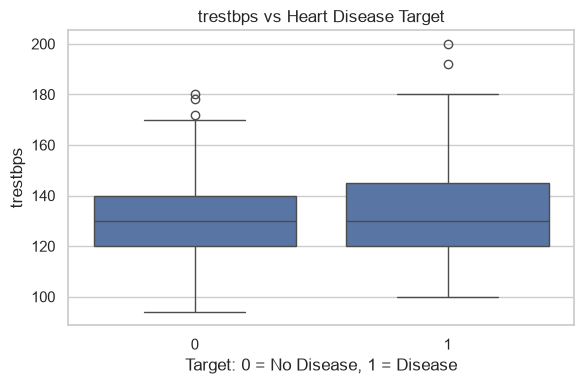

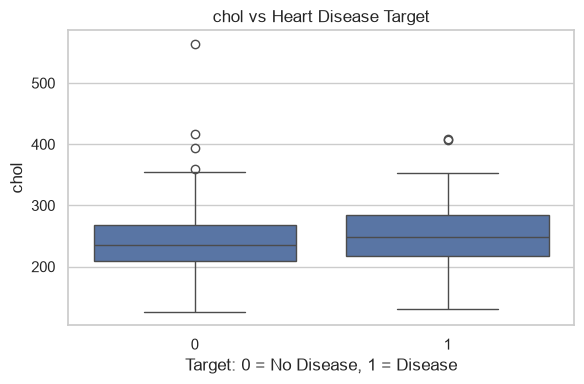

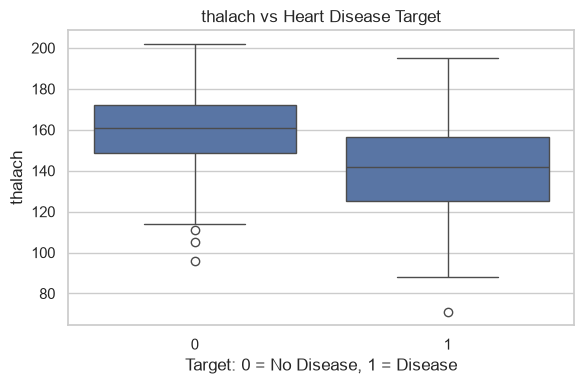

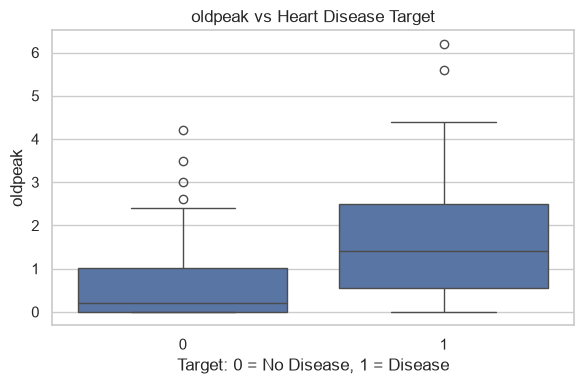

In [11]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

for feature in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="target", y=feature)
    plt.title(f"{feature} vs Heart Disease Target")
    plt.xlabel("Target: 0 = No Disease, 1 = Disease")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.savefig(FIGURE_PATH / f"{feature}_vs_target_boxplot.png", dpi=300)
    plt.show()

### 11. Categorical Feature Relationships with Target

Several variables in the dataset are categorical or ordinal in nature, even though they may be stored as numeric values. Examples include chest pain type, fasting blood sugar category, resting ECG results, exercise-induced angina, slope, number of major vessels, and thalassemia status.

Grouped count plots are used to compare each categorical feature against the target variable. This helps identify whether certain categories appear more frequently in patients with heart disease.

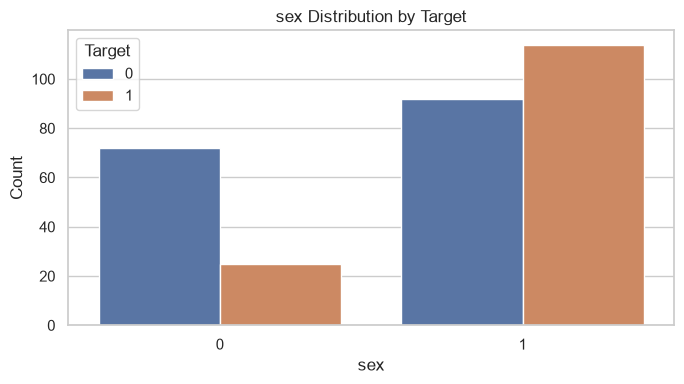

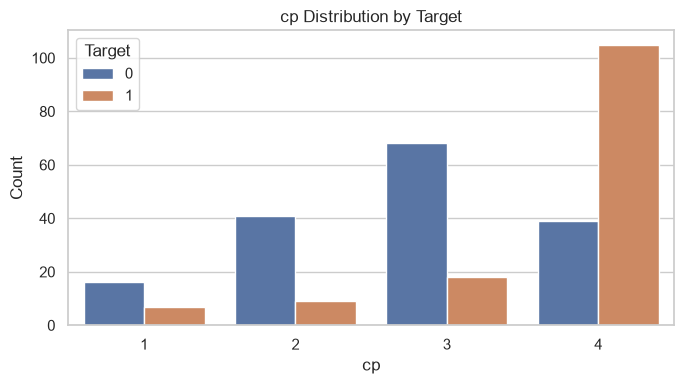

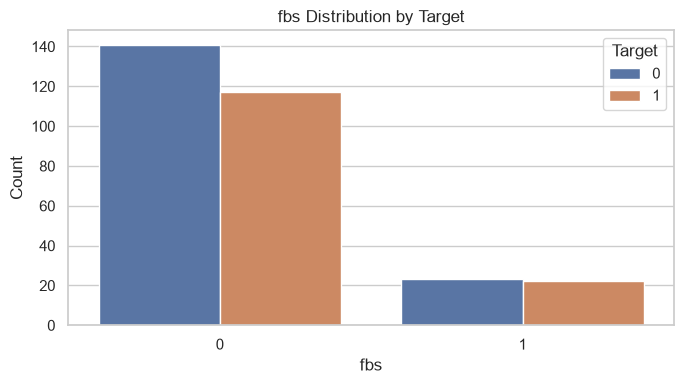

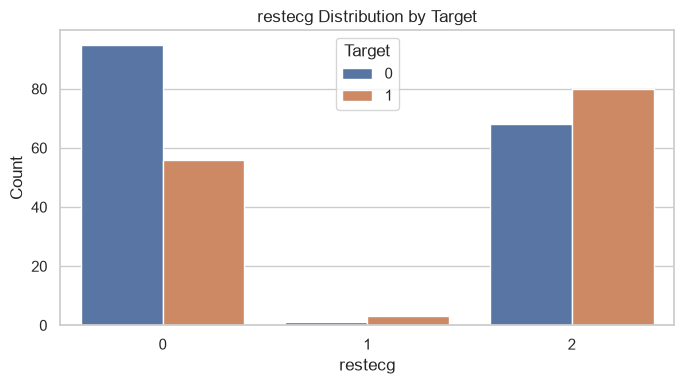

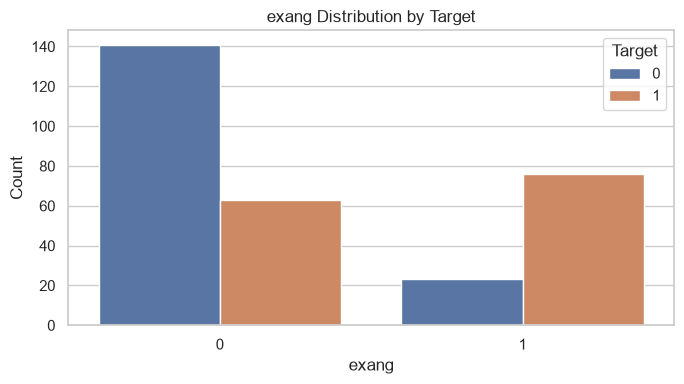

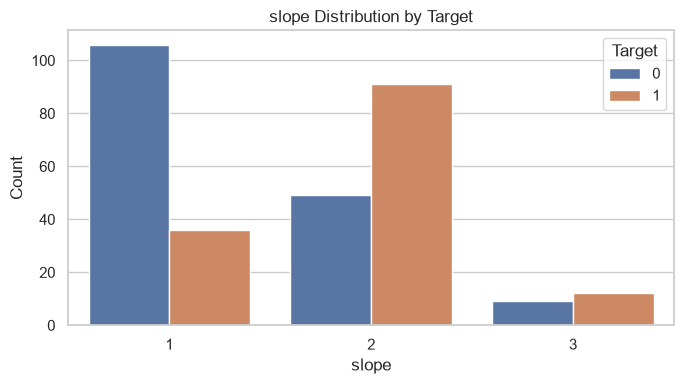

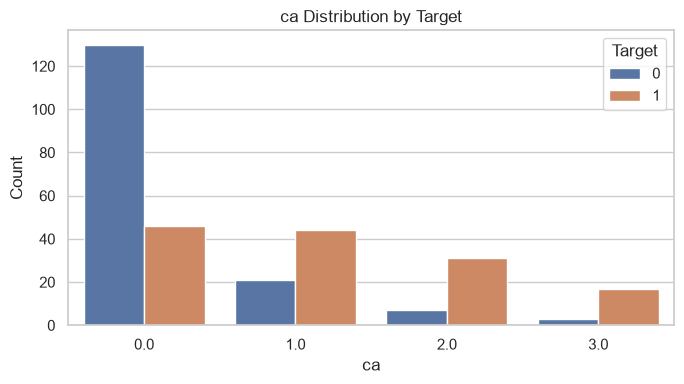

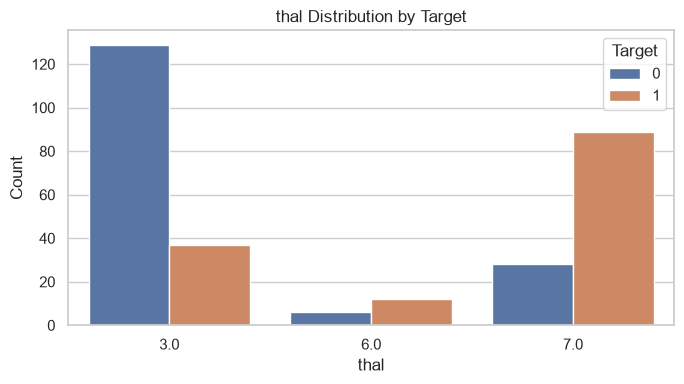

In [12]:
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

for feature in categorical_features:
    if feature in df.columns:
        plt.figure(figsize=(7, 4))
        sns.countplot(data=df, x=feature, hue="target")
        plt.title(f"{feature} Distribution by Target")
        plt.xlabel(feature)
        plt.ylabel("Count")
        plt.legend(title="Target")
        plt.tight_layout()
        plt.savefig(FIGURE_PATH / f"{feature}_by_target.png", dpi=300)
        plt.show()

### 12. Save Final Cleaned Dataset

The cleaned dataset is saved again to the `data/processed/` folder for use in the next stage of the project.

In this notebook, no final imputation, scaling, or encoding is permanently applied to the dataset. Those preprocessing steps will be handled later using an `sklearn Pipeline` and `ColumnTransformer`. This is the preferred approach because it prevents data leakage and ensures the same preprocessing logic is reused during model training and API inference.

In [13]:
df.to_csv("../data/processed/heart_disease_clean.csv", index=False)
print("Clean dataset saved successfully.")

Clean dataset saved successfully.


### 13. EDA Summary

The exploratory data analysis provided the following key insights:

1. The Heart Disease UCI dataset was successfully loaded and reviewed.
2. The target variable was prepared as a binary classification label.
3. Dataset structure, data types, and descriptive statistics were examined.
4. Missing value analysis was performed to identify features requiring imputation.
5. Class distribution was reviewed to understand target balance.
6. Histograms were generated to study numerical feature distributions.
7. A correlation heatmap was created to examine relationships between variables.
8. Boxplots were used to compare numerical features across target classes.
9. Grouped count plots were used to analyze categorical feature behavior against the target.

Based on this analysis, the dataset is suitable for binary classification after appropriate preprocessing. In the next stage, missing value imputation, feature scaling, categorical encoding, model training, hyperparameter tuning, and evaluation will be implemented using reproducible machine learning pipelines.